The goal of this project is to predict student GPAs using various metrics.

# The Dataset

The following dataset will be used: https://drive.google.com/file/d/14jkgeXF1_0U446EWP1Ee8L8UoJM53TYg/view?usp=sharing

It contains:

*   id--a student's id
*   lat--student's home latittude
*   lon--student's home longitude
*   avg_hours_studided--how many hours this student studied every week on average this semester
*   parents_income--the student's parent's income in dollars.
*   major--the student's major
*   tutoring--whether or not the student received tutoring this semester
*   semester--what semester it is
*   credits--how many credits the student took this semester
*   student_age--how old the student is
*   student_year--what year of college the student is
*   year--what year it is

# Introduction

In this project, I plan on using the data lifecycle to predict student's GPA based on different attributes such as hours studied. 

The dataset provided consists of several columns containing different information about students. Each entry represents a given semester at the university and the entries are distinguished by the student's id.

However, predicting a student's GPA can be a complex task due to several reasons. Firstly, missing data or data that is inputted incorrectly needs to be accounted for. Secondly, the student's home location is inputted as a coordinate, which can be confusing to encode into the model.

Despite the difficulties, developing an algorithm to predict a student's GPA can be highly valuable. Firstly, the model can assist schools in identifying students who may require support to improve their academic performance. Next, the algorithm can aid in evaluating and optimizing various attributes, such as tutoring or increasing the hours studied, by measuring their impact on students' GPA.

# Data Exploration

I will begin by analyzing important variables and whether or not they will be useful to the model going forward. I will also attempt to answer the following questions:

* Does this school have transfer students?
* What is the median length of attendence at this university?
* Do you think this university has any one credit classes?
* Is grade inflation a problem at this university?
* In what area do you think the Univesrity might be located?
* Does tutoring make a stastically significant difference in grade?
* How often do students switch majors?
* Do different majors have different GPA distributions?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("my_data.csv")

Variable: id
Min: 13251
Max: 66282


<AxesSubplot:>

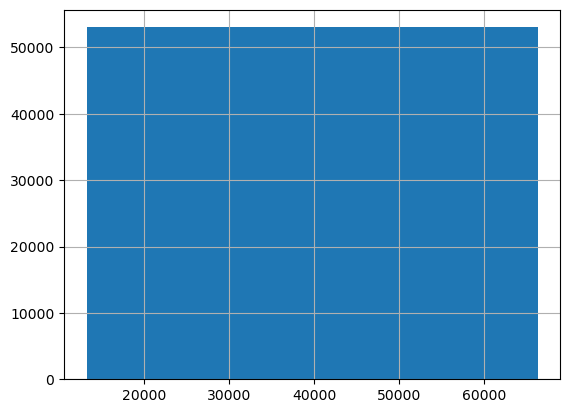

In [2]:
# id
print("Variable: id")
print("Min:", df["id"].min())
print("Max:", df["id"].max())
df["id"].hist()

The student ID is a unique identifier and may not provide much useful information for the analysis. It probably won't be too useful as far as the model is concerned.

Variable: lat
Min: 32.04884563
Max: 40.19658486


<AxesSubplot:>

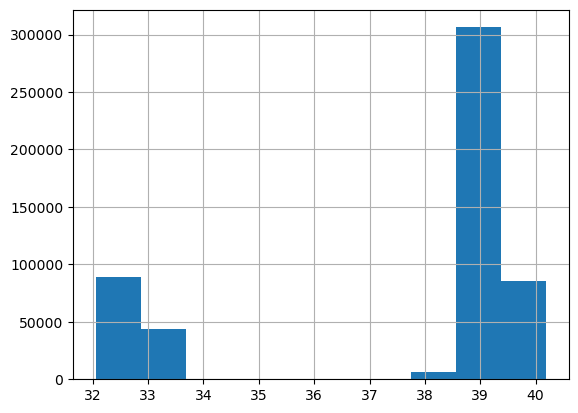

In [3]:
# lat
print("Variable: lat")
print("Min:", df["lat"].min())
print("Max:", df["lat"].max())
df["lat"].hist()

Latitude values provide information on the location of students' homes. It might be useful for analyzing regional trends or clustering students based on their residential areas. There doesn't seem to be outliers in this dataset.

Variable: lon
Min: -94.7222828
Max: -75.79067949


<AxesSubplot:>

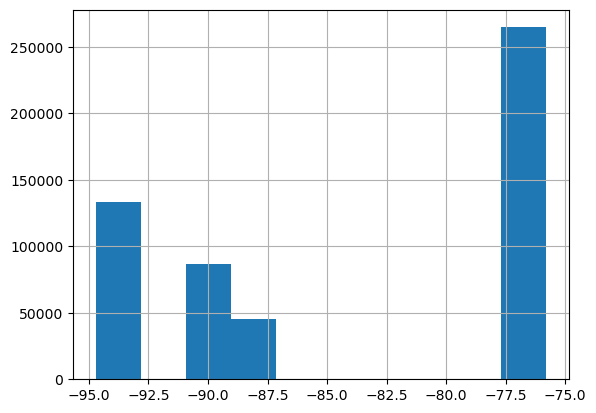

In [4]:
# lon
print("Variable: lon")
print("Min:", df["lon"].min())
print("Max:", df["lon"].max())
df["lon"].hist()

Longitude values provide information on the location of students' homes. It might be useful for analyzing regional trends or clustering students based on their residential areas. There don't seem to be outliers in this dataset.

Variable: avg_hours_studied
Min: 0
Max: 10000


<AxesSubplot:>

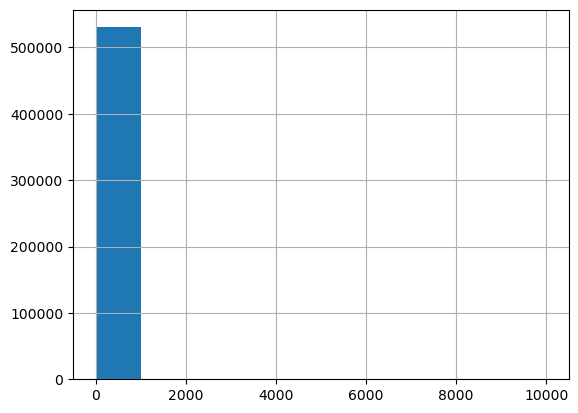

In [5]:
# avg_hours_studied
print("Variable: avg_hours_studied")
print("Min:", df["avg_hours_studied"].min())
print("Max:", df["avg_hours_studied"].max())
df["avg_hours_studied"].hist()

The average hours studied per week provide information about students' study habits and it can useful in identifying correlations with GPA or academic performance. This will definitely be included in the model going forward. There seems to be an outlier at 10000 which needs to be accounted for.

Variable: parents_income
Min: 21619.07236
Max: 186445.7425


<AxesSubplot:>

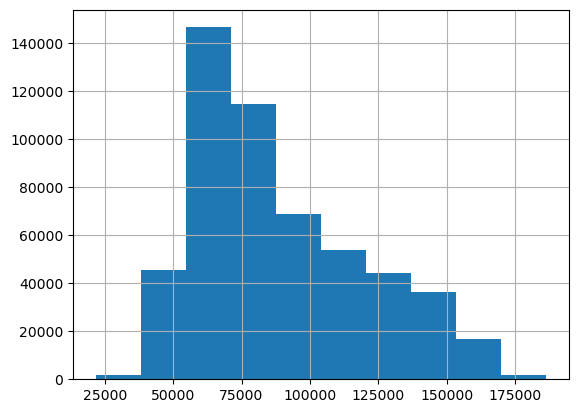

In [6]:
# parents_income
print("Variable: parents_income")
print("Min:", df["parents_income"].min())
print("Max:", df["parents_income"].max())
df["parents_income"].hist()

Parents' income can provide insight into students' educational resources: it may help analyze the impact of socioeconomic status on academic outcomes.

Variable: major
Major with the most counts: Physics
Count: 106885
Major with the least counts: English
Count: 105281


<AxesSubplot:>

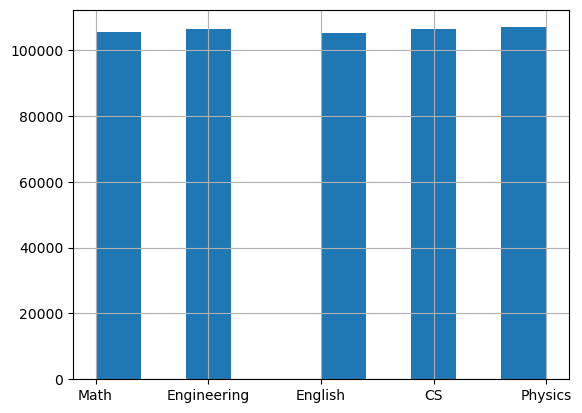

In [7]:
# major
print("Variable: major")

# Count the occurrences of each major
major_counts = df["major"].value_counts()

# Major with the most counts
major_most = major_counts.idxmax()
count_most = major_counts.max()
print("Major with the most counts:", major_most)
print("Count:", count_most)

# Major with the least counts
major_least = major_counts.idxmin()
count_least = major_counts.min()
print("Major with the least counts:", major_least)
print("Count:", count_least)

df["major"].hist()

Analyzing the distribution of majors can be important going forward because there might be correlations between majors and GPA distributions. For example, some majors might be harder than others. It is important to note that the distribution of the majors seem to be even.

Variable: tutoring
Tutoring with the most counts: No
Count: 489690
Tutoring with the least counts: Yes
Count: 14414


<AxesSubplot:>

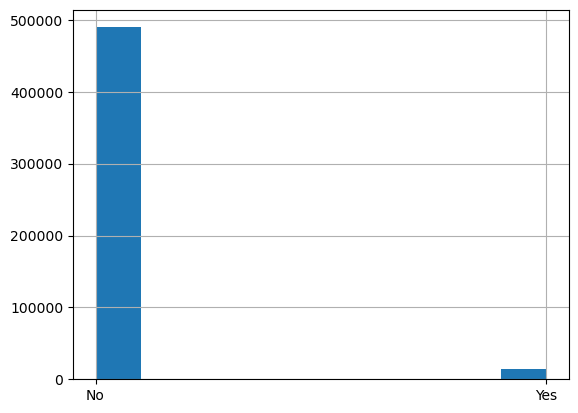

In [8]:
# tutoring
print("Variable: tutoring")

# Count the occurrences of each major
tutoring_counts = df["tutoring"].value_counts()

tutoring_most = tutoring_counts.idxmax()
count_most = tutoring_counts.max()
print("Tutoring with the most counts:", tutoring_most)
print("Count:", count_most)

tutoring_least = tutoring_counts.idxmin()
count_least = tutoring_counts.min()
print("Tutoring with the least counts:", tutoring_least)
print("Count:", count_least)

df["tutoring"].hist()

The tutoring column may be useful because it is important to analyze the impact of tutoring on academic performance because the students may be putting in more effort into their classes.

Variable: semester
Semester with the most counts: Fall
Count: 265160
Semester with the least counts: Spring
Count: 265159


<AxesSubplot:>

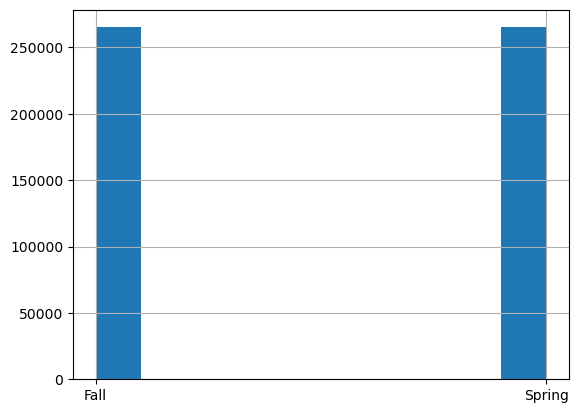

In [9]:
# semester
print("Variable: semester")

# Count the occurrences of each semester
semester_counts = df["semester"].value_counts()

semester_most = semester_counts.idxmax()
count_most = semester_counts.max()
print("Semester with the most counts:", semester_most)
print("Count:", count_most)

semester_least = semester_counts.idxmin()
count_least = semester_counts.min()
print("Semester with the least counts:", semester_least)
print("Count:", count_least)

df["semester"].hist()

The semester column can be useful to identify patterns across different academic terms. However, it probably won't be too useful to include in the model by itself because since the semester alone doesn't tell us about at what in time we are at.

Variable: credits
Min: 9
Max: 18


<AxesSubplot:>

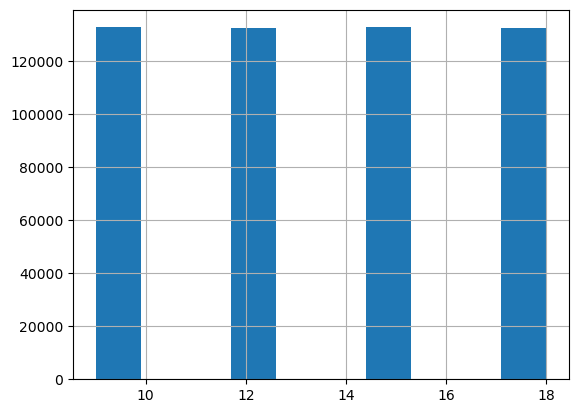

In [10]:
# credits
print("Variable: credits")
print("Min:", df["credits"].min())
print("Max:", df["credits"].max())
df["credits"].hist()

The credits column may be useful to analyze the relationship between credit load and GPA. For example, it is possible that a larger credit load may be harder.

Variable: student_age
Min: 17
Max: 33


<AxesSubplot:>

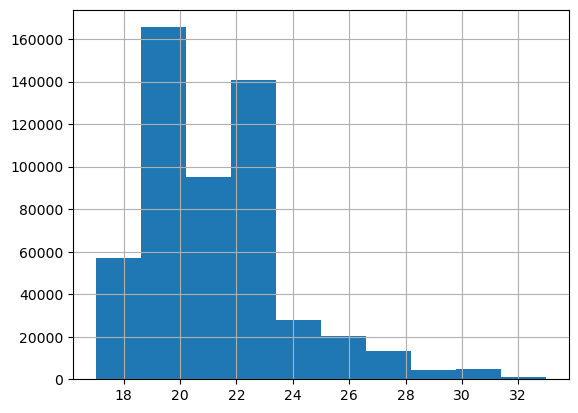

In [11]:
# student_age
print("Variable: student_age")
print("Min:", df["student_age"].min())
print("Max:", df["student_age"].max())
df["student_age"].hist()

The student's age probably won't be too useful going forward because there isn't a clear way age relates to GPAs (most of the students have a similar age). In addition, we don't want our model to overfit.

Variable: student_year
Student year with the most counts: Senior
Count: 212127
Student year with the least counts: Freshman
Count: 106064


<AxesSubplot:>

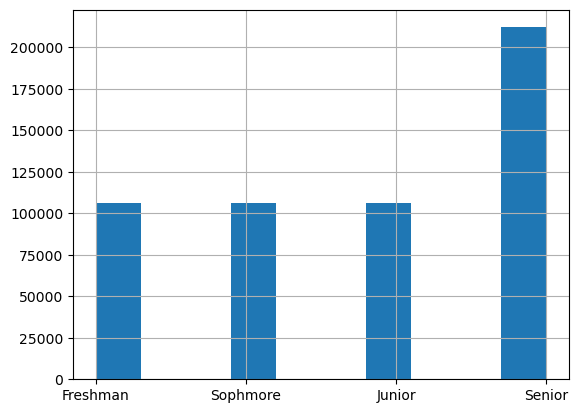

In [12]:
# student_year
print("Variable: student_year")

# Count the occurrences of each student_year
student_year_counts = df["student_year"].value_counts()

student_year_most = student_year_counts.idxmax()
count_most = student_year_counts.max()
print("Student year with the most counts:", student_year_most)
print("Count:", count_most)

student_year_least = student_year_counts.idxmin()
count_least = student_year_counts.min()
print("Student year with the least counts:", student_year_least)
print("Count:", count_least)

df["student_year"].hist()

The student_year column can be useful to assess GPA patterns across different academic years. Since there are more seniors than other years and it is possible that clases get harder as you progress through school, it can be useful to account for this in the model.

Variable: year
Year with the most counts: 2010
Count: 33156
Year with the least counts: 2005
Count: 3369


<AxesSubplot:>

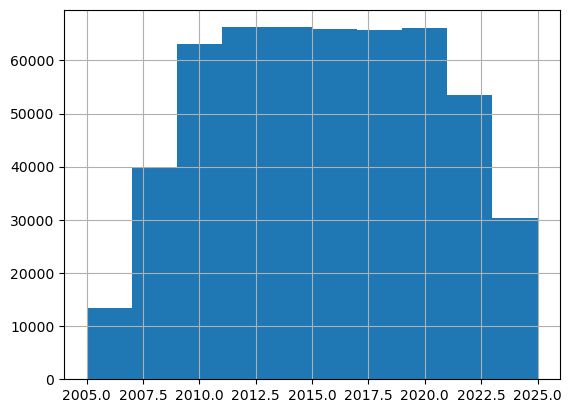

In [13]:
# year
print("Variable: year")

# Count the occurrences of each year
year_counts = df["year"].value_counts()

year_most = year_counts.idxmax()
count_most = year_counts.max()
print("Year with the most counts:", year_most)
print("Count:", count_most)

year_least = year_counts.idxmin()
count_least = year_counts.min()
print("Year with the least counts:", year_least)
print("Count:", count_least)

df["year"].hist()

The year column can be useful to analyze trends or changes in student attributes over time. It will be important to include this along with what semester it is in the model.

Minimum GPA: 0.0
Maximum GPA: 4.1


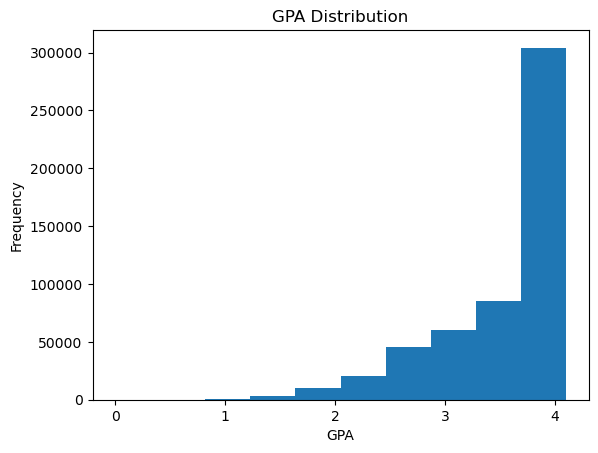

In [14]:
min_gpa = df['gpa'].min()
max_gpa = df['gpa'].max()
print("Minimum GPA:", min_gpa)
print("Maximum GPA:", max_gpa)

plt.hist(df['gpa'], bins=10)
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.title('GPA Distribution')
plt.show()

It is important to note that there are some GPAs over 4. Since a GPA over 4 is not possible at most schools, I will convert those values to 4, which is the highest value possible.

# Does this school have transfer students?
First, we need to determine when the students started taking classes. If the student did not start fall freshmen year, they must have transferred in.

In [15]:
# Create a new column 'year_semester_encoded' by encoding 'year' and 'semester'
df['year_semester_encoded'] = df['year'] * 10 + (df['semester'] == 'Fall').astype(int)

# Sort the df by student id and year_semester_encoded
df = df.sort_values(['id', 'year_semester_encoded'], ascending=True)

# Find the first entry for the students
first_entry = df.groupby('id').first()

# Identify transfer students
mask = ((first_entry['student_year'] != 'Freshman') | (first_entry['semester'] != 'Fall'))
transfer_students = first_entry[mask]

print(transfer_students)

Empty DataFrame
Columns: [Unnamed: 0, lat, lon, gpa, avg_hours_studied, parents_income, major, tutoring, semester, year, credits, student_age, student_year, year_semester_encoded]
Index: []


Since, the result is empty, we have no transfer students that transferred in. However, we need to check if students transferred out of the school. To check this, we check how many semesters each student stayed at the school. If we look at the data, we realize that a lot of the students stayed for 10 semesters, which meant that they graduated their 5th year. I will look for students that did not take 10 semesters.

In [16]:
# Count the number of entries for each student
semester_counts = df['id'].value_counts()

# Filter for less than 10
ids_less_than_10_semesters = semester_counts[semester_counts < 10]
print(ids_less_than_10_semesters)

66282    9
Name: id, dtype: int64


Since no students stayed for less than 10 semesters, it is reasonable to deduce that no students transferred out.

# What is the median length of attendence at this university?

<AxesSubplot:>

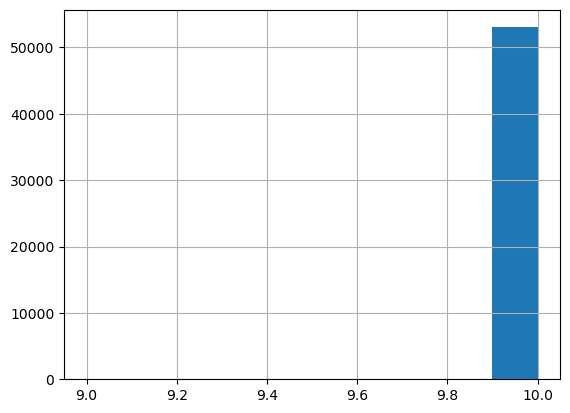

In [17]:
semester_counts = df['id'].value_counts()
semester_counts.hist()

Since all students stayed for exactly 10 semesters, the median length of attendance is 10 semesters.

# Do you think this university has any one credit classes?

In [18]:
print(df["credits"].unique())

[15  9 18 12]


Since all the credits are in multiples of 3, it is unlikely there are any one credit classes (it is unlikely for students to take 3 one credit classes).

# Is grade inflation a problem at this university?

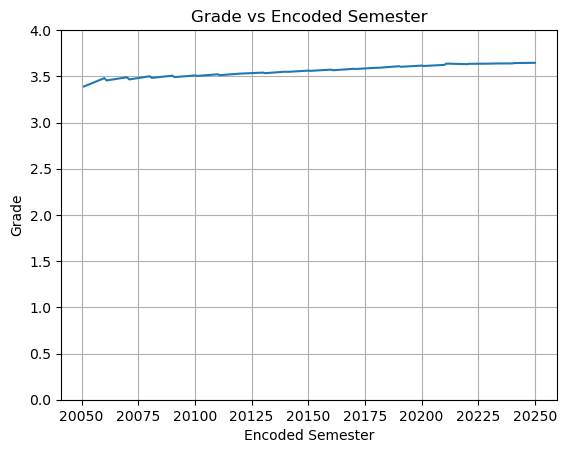

In [19]:
from scipy.stats import ttest_ind

# Plot grade vs encoded semester
semester_means = df.groupby('year_semester_encoded')['gpa'].mean()
plt.plot(semester_means.index, semester_means.values)
plt.xlabel('Encoded Semester')
plt.ylabel('Grade')
plt.ylim(0, 4)
plt.title('Grade vs Encoded Semester')
plt.grid(True)
plt.show()

Since the grade appears to be going up, we need to run a hypothesis test to make sure.

In [20]:
# Perform t-test
first_semester = df[df['year_semester_encoded'] == semester_means.index[0]]['gpa']
last_semester = df[df['year_semester_encoded'] == semester_means.index[-1]]['gpa']
test = ttest_ind(first_semester, last_semester)

print("P-Value: ", test.pvalue)

P-Value:  4.72244167393782e-67


Since the p-value is incredibly small and it represents the chance that the GPA change occurred by chance, there is likely grade inflation at this school.

# In what area do you think the Univesrity might be located?

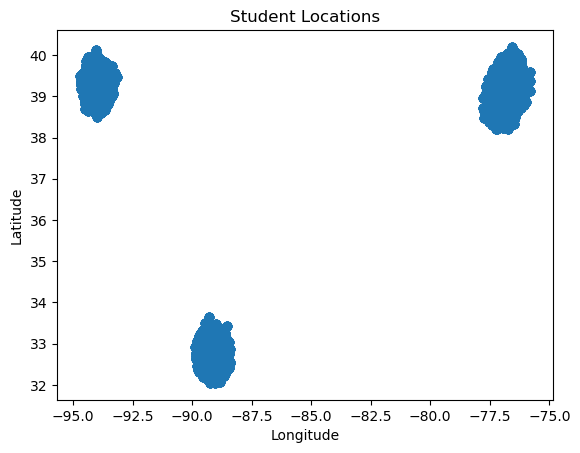

In [21]:
plt.scatter(df['lon'], df['lat'])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Student Locations')
plt.show()

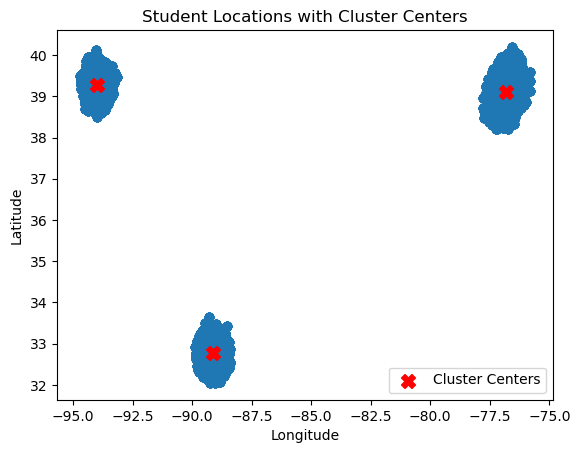

Cluster Coordinates (Highest Count): [ 39.10397684 -76.81294061]


In [22]:
from sklearn.cluster import KMeans

X = df[['lat', 'lon']]
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

# Get the coordinates of the cluster centers
cluster_centers = kmeans.cluster_centers_

plt.scatter(X['lon'], X['lat'])
plt.scatter(cluster_centers[:, 1], cluster_centers[:, 0], color='red', marker='X', s=100, label='Cluster Centers')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Student Locations with Cluster Centers')
plt.legend()
plt.show()

labels = kmeans.labels_
cluster_counts = pd.Series(labels).value_counts()
highest_count_cluster = cluster_counts.idxmax()
highest_count_cluster_center = kmeans.cluster_centers_[highest_count_cluster]
print("Cluster Coordinates (Highest Count):", highest_count_cluster_center)

We return the cluster center with the highest count, so these are the coordinates where the school is likely to be located. The general region is in Maryland between DC and Baltimore.

# Does tutoring make a stastically significant difference in grade?

In [23]:
tutoring_yes = df[df['tutoring'] == 'Yes']
tutoring_no = df[df['tutoring'] == 'No']

test = ttest_ind(tutoring_yes['gpa'], tutoring_no['gpa'])
print("P-Value: ", test.pvalue)

# Print the average GPAs
print("Average GPA (Tutoring: Yes):", df[df['tutoring'] == 'Yes']['gpa'].mean())
print("Average GPA (Tutoring: No):", df[df['tutoring'] == 'No']['gpa'].mean())

P-Value:  0.0
Average GPA (Tutoring: Yes): 3.364975718051891
Average GPA (Tutoring: No): 3.566311809514241


Since the p-value is essentially 0, this means that there is a ~0% chance that the difference is due to chance. Tutoring does make a statistically significant difference in grade, and it is interesting to note that those who received tutoring actually did worse. This should definitely be accounted for in the model.

# How often do students switch majors?

In [24]:
switch_count = df.groupby('id')['major'].nunique()
average_switch_count = switch_count.mean()
print("Average number of times students switch majors:", average_switch_count - 1)

Average number of times students switch majors: 0.06861894705083715


It is uncommon for students to change majors with an average of 0.069 switches for each student.

# Do different majors have different GPA distributions?

In [25]:
from scipy.stats import f_oneway

major_gpas = {}
for major, major_group in df.groupby('major'):
    major_gpas[major] = major_group['gpa'].values

# Perform the ANOVA test
fstat, pvalue = f_oneway(*major_gpas.values())

print("P-value: ", pvalue)

P-value:  0.0


Since the p-value is really low, it means that the different majors likely do have different GPA distributions. We will need to account for this in the model.

# Data Cleaning

For this section, I will deal with outliers and missing data. In addition, I will one-hot encode variables for analysis. One challenge is encoding the latitude and longitude because there isn't a straightforward way of categorizing it.

I plan on one-hot encoding the students based on which cluster center they belong to. I renamed the cluster center representing the school (the highest count) as "School". I also one plan on one-hot encoding tutoring, and major as the hypothesis tests show that these are important. In addition, I will standardize variables such as Parent's Income so that they will have an equal weight in the model.

In [26]:
df['Cluster'] = labels

# Create new columns for cluster centers using one-hot encoding
for i in range(3):
    df[f'Cluster_Center_{i+1}'] = (df['Cluster'] == i).astype(int)

cluster_counts = df.iloc[:, -3:].sum()
highest_count_cluster = cluster_counts.idxmax()
df.rename(columns={highest_count_cluster: 'School'}, inplace=True)
df['avg_hours_studied'] = (df['avg_hours_studied'] - df['avg_hours_studied'].mean()) / df['avg_hours_studied'].std()
df['parents_income'] = (df['parents_income'] - df['parents_income'].mean()) / df['parents_income'].std()
df['credits'] = (df['credits'] - df['credits'].mean()) / df['credits'].std()
df['year_semester_encoded'] = (df['year_semester_encoded'] - df['year_semester_encoded'].mean()) / df['year_semester_encoded'].std()

In [27]:
tutoring_encoded = pd.get_dummies(df['tutoring'], prefix='tutoring')
major_encoded = pd.get_dummies(df['major'], prefix='major')
student_year_encoded = pd.get_dummies(df['student_year'], prefix='student_year')
df_encoded = pd.concat([df, tutoring_encoded, major_encoded, student_year_encoded], axis=1)
df = df_encoded
print(df_encoded.head())

   Unnamed: 0     id        lat        lon   gpa  avg_hours_studied  \
0           0  13251  38.878529 -76.776049  3.64          -0.004227   
1           1  13251  38.878529 -76.776049  3.65          -0.004227   
2           2  13251  38.878529 -76.776049  4.00          -0.004227   
3           3  13251  38.878529 -76.776049  4.00          -0.014233   
4           4  13251  38.878529 -76.776049  3.30          -0.014233   

   parents_income major tutoring semester  ...  tutoring_Yes  major_CS  \
0       -0.653157  Math       No     Fall  ...             0         0   
1       -0.653157  Math       No   Spring  ...             0         0   
2       -0.653157  Math       No     Fall  ...             0         0   
3       -0.653157  Math       No   Spring  ...             0         0   
4       -0.653157  Math       No     Fall  ...             0         0   

   major_Engineering major_English  major_Math  major_Physics  \
0                  0             0           1              0  

I next found out which columns have missing data.

In [28]:
# Check for missing data
missing_data = df.isnull().sum()
columns_with_missing_data = missing_data[missing_data > 0].index

print(columns_with_missing_data)

Index(['tutoring'], dtype='object')


To fill in the tutoring column, I will just use the entries with the same IDs that do have values for that column to fill in the missing values. Next, it is impossible for students to study more than 24 hours a day. I will instead replace the outliers with the upper quartile for hours studied, as these students supposedly studied a lot. I will also replace any GPA over 4.0 with 4.0 as this is the max GPA.

In [29]:
df['tutoring'] = df.groupby('id')['tutoring'].ffill().bfill()
q3 = df['avg_hours_studied'].quantile(0.75)
df.loc[df['avg_hours_studied'] > 24, 'avg_hours_studied'] = q3
df.loc[df['gpa'] > 4.0, 'gpa'] = 4.0

# Evaluation

I plan on using Mean Squared Error to evaluate the models. Since MSE provides a number and I have multiple models with the same data, I can compare between the models as the number will be relative. In addition, GPA is a continuous variable.

There are also several ways why evaluating this problem might be tricky. Firstly, if I select the wrong features to use in my models, I might be overfitting my model or introducing extra noise. In addition, since there is a temporal aspect to this problem, I need to account for this so my evaluation takes this into account. One shortcomming of using MSE is how it outputs a number, and it can be hard to determine what the number means. I address this by comparing between the models and generating the MSE of a random guess with the mean GPA.

# Modeling

In this section, I will utilize different models and adjust the hyperparameters for each.

# Decision Tree

In [30]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Select columns for features
feature_columns = ['avg_hours_studied', 'parents_income', 'credits', 'year_semester_encoded', 'School']
cluster_columns = [col for col in df.columns if col.startswith('Cluster_Center_')]
tutoring_columns = [col for col in df.columns if col.startswith('tutoring_')]
major_columns = [col for col in df.columns if col.startswith('major_')]
student_year_columns = [col for col in df.columns if col.startswith('student_year_')]
feature_columns.extend(cluster_columns)
feature_columns.extend(tutoring_columns)
feature_columns.extend(major_columns)
feature_columns.extend(student_year_columns)
print(feature_columns)

# Split the data into train and test sets
X = df[feature_columns]  # Features
y = df['gpa']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the decision tree model
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

['avg_hours_studied', 'parents_income', 'credits', 'year_semester_encoded', 'School', 'Cluster_Center_2', 'Cluster_Center_3', 'tutoring_No', 'tutoring_Yes', 'major_CS', 'major_Engineering', 'major_English', 'major_Math', 'major_Physics', 'student_year_Freshman', 'student_year_Junior', 'student_year_Senior', 'student_year_Sophmore']
Mean Squared Error (MSE): 0.17473314885352237


In [31]:
from sklearn.ensemble import RandomForestRegressor

X = df[feature_columns]  # Features
y = df['gpa']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.09868021138812413


In this model, the hyperparameters would be n_estimators. I chose 100 because this was the default and I wanted to have enough estimators to differentiate between one decision tree.

In [32]:
from sklearn.neighbors import KNeighborsRegressor

X = df[feature_columns]  # Features
y = df['gpa']  # Target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsRegressor(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.3019835163465246


In this model, the hyperparameters would be m_neighbors. I chose 3 for efficiency reasons. Increasing this number would lead to changes in the MSE.

Finally, I will evaluate the model by comparing the MSE with the MSE of just guessing the mean GPA.

In [33]:
mean_value = y_test.mean()

# Create an array of the same length as y_test with the mean value
meanArr = pd.Series(data=mean_value, index=range(len(y_test)))
mse = mean_squared_error(y_test, meanArr)

print("Mean Squared Error compared to just using mean GPA to predict:", mse)

Mean Squared Error compared to just using mean GPA to predict: 0.361596700278821


# Conclusion

The goal of the project was to predict GPAs based on a given list of students and features. I first analyzed the data through data exploration to determine which features (such as whether they were tutored or not) were useful. Then I one-hot encoded the categorical variables that I planned on using. Something important here was combining the semester and year together to provide a timeline on which to base the model. Next, I did some data cleaning, where I dealt with outliers, standardized variables, and filled in missing data. Finally, I chose three models: Decision Tree, Random Forest, and K-Nearest Neighbors, and evaluated them based with Mean Squared Error. Random Forest appears to have done the best, with the smallest MSE. I feel like my model was most successful because the errors were lower than the errors I received if I just guessed the mean GPA. Going forward, one piece of data that could be useful can be attendance (to see if students who attended more had better GPAs because they retianed the information better). Another picece of data that may be useful would be the average level of the course (100s, 200s, etc.) to see if higher leveled courses made it harder to receive a higher GPA.